🔹 1. Load and Inspect the Data

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\USER\Desktop\AI & ML INTERNSHIP\day5\heart.csv")
print(df.head())
print(df.info())
print(df.describe())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

🔹 2. Preprocessing
*Encode categorical features if needed (e.g., cp, thal, slope)

*Normalize numeric features (optional for trees, but useful for comparisons)

In [3]:
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

🔹 3. Split Dataset

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

🌳 4. Decision Tree with Grid Search

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': [3, 5, 7, None], 'min_samples_split': [2, 5, 10]}
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search_dt.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [3, 5, 7, None],
                         'min_samples_split': [2, 5, 10]})

In [9]:
best_dt = grid_search_dt.best_estimator_
print("Best Decision Tree Params:", grid_search_dt.best_params_)

Best Decision Tree Params: {'max_depth': None, 'min_samples_split': 2}


📈 5. Evaluate Decision Tree

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_dt = best_dt.predict(X_test)
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



📊 6. Visualize the Tree

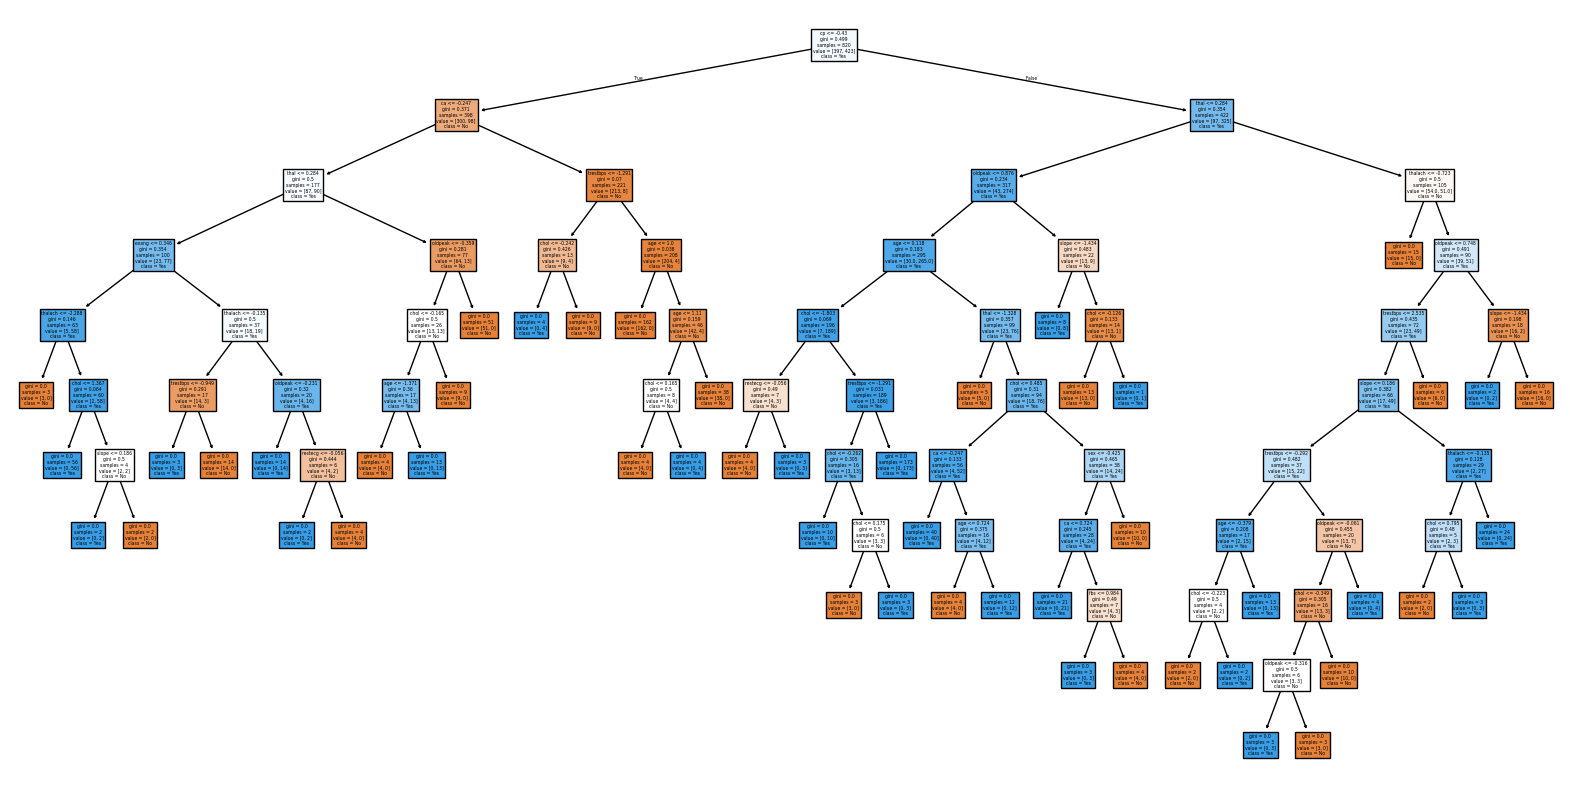

In [13]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=X.columns, class_names=["No", "Yes"], filled=True)
plt.show()

🌲 7. Train and Evaluate Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [17]:
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", rf.score(X_test, y_test))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9073170731707317
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       102
           1       0.88      0.94      0.91       103

    accuracy                           0.91       205
   macro avg       0.91      0.91      0.91       205
weighted avg       0.91      0.91      0.91       205



🔍 8. Feature Importances

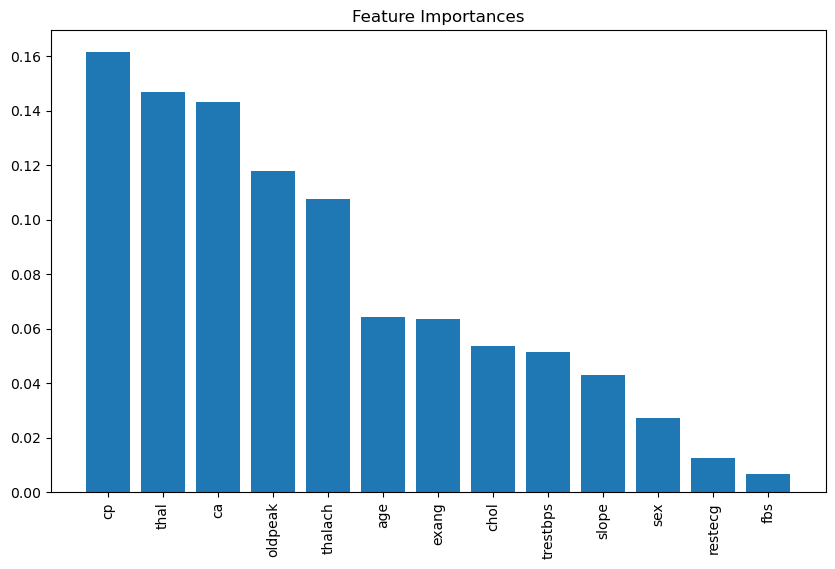

In [37]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.show()

🔁 9. Cross-Validation Comparison

In [21]:
from sklearn.model_selection import cross_val_score

dt_cv = cross_val_score(best_dt, X, y, cv=5).mean()
rf_cv = cross_val_score(rf, X, y, cv=5).mean()
print("CV Accuracy - Decision Tree:", dt_cv)
print("CV Accuracy - Random Forest:", rf_cv)

CV Accuracy - Decision Tree: 1.0
CV Accuracy - Random Forest: 0.9609756097560975


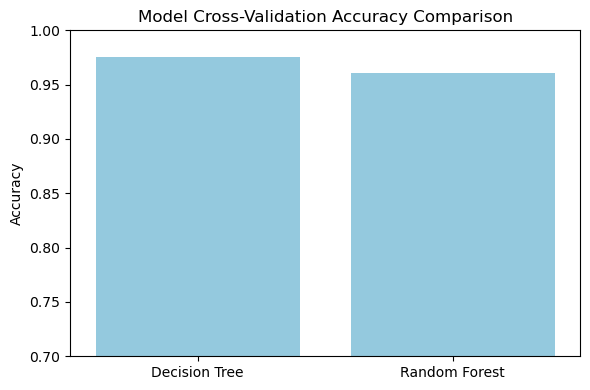

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.barplot(x=models, y=scores, color="skyblue")  # fixed: direct color
plt.title("Model Cross-Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1)
plt.tight_layout()
plt.show()


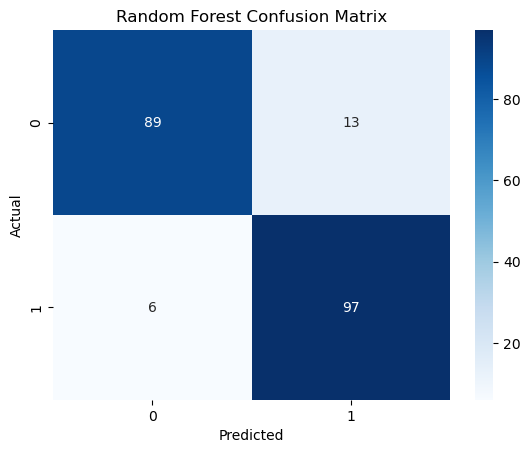

In [39]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


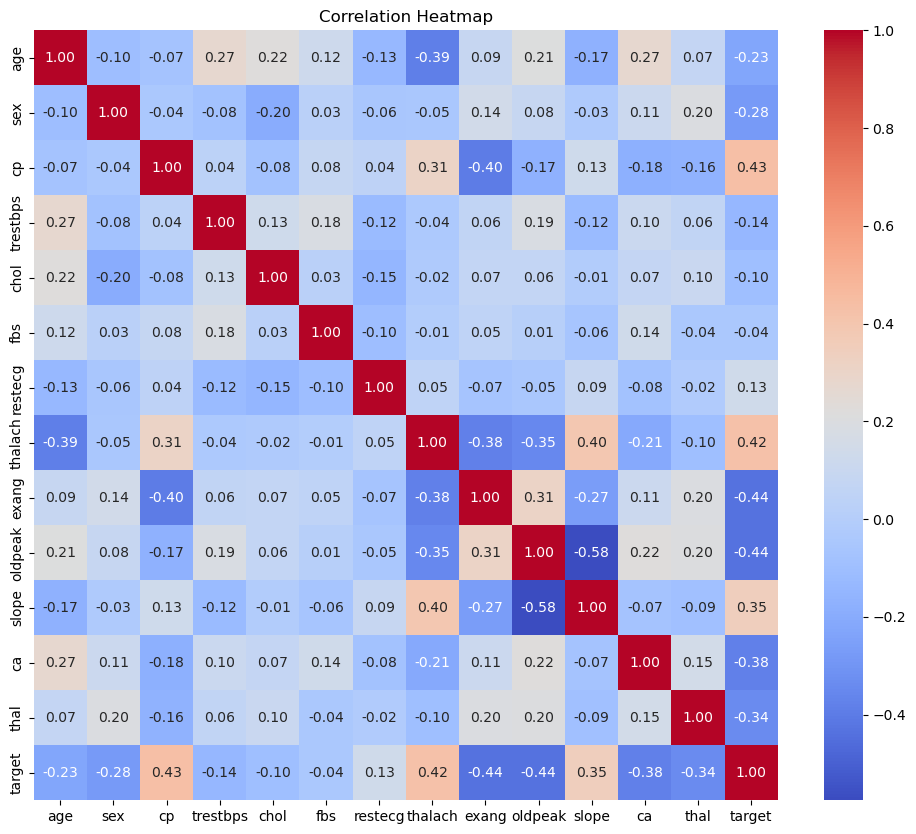

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
